<a href="https://colab.research.google.com/github/Paytonscott03/ES2245/blob/main/es2245_lab11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 11: Machine Learning Applications in the Geosciences
**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

**Estimated Time:** 60 Minutes  

In this lab, we will explore how data science and machine learning are revolutionizing the geosciences. We will cover four distinct problems using four different algorithms: Linear Regression, K-Means Clustering, Multilayer Perceptrons (MLP), and Recurrent Neural Networks (RNN).

## 0. Setup and Environment
Run the cell below to import the necessary libraries. Note: You will need `tensorflow` installed for the final exercise.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

print("Libraries imported successfully. Environment is ready!")

Libraries imported successfully. Environment is ready!


---
## 1. Geodesy: Measuring Tectonic Uplift (Linear Regression)

**Scenario:** You have GNSS (GPS) data from a station located near a subduction zone. We want to determine the rate of vertical land motion (tectonic uplift) over a 10-year period.

**Your Task:** Calculate the uplift rate (mm/yr) by fitting a linear model to the noisy displacement data. Fill in the missing code indicated by `___`.

Calculated Uplift Rate: 4.23 mm/yr


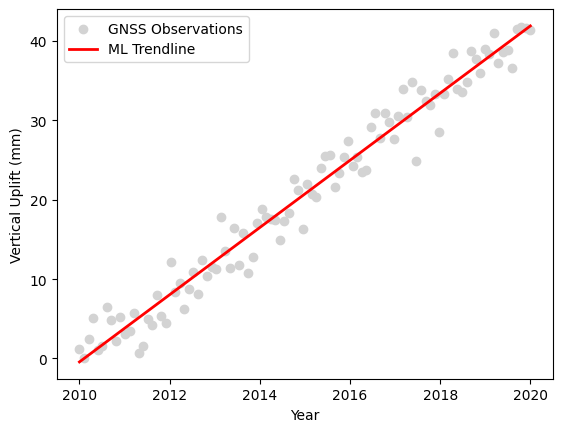

In [ ]:
from sklearn import linear_model
# Synthetic Data: Time (years) vs. Vertical Displacement (mm)
np.random.seed(42)
years = np.linspace(2010, 2020, 100).reshape(-1, 1)
# True uplift is 4.2 mm/yr, with sensor noise added
vertical_displacement = 4.2 * (years - 2010) + np.random.normal(0, 2.5, 100).reshape(-1, 1)

# --- STUDENT CODE HERE ---
# 1. Initialize the LinearRegression model
model = LinearRegression()

# 2. Fit the model using 'years' as your X and 'vertical_displacement' as your y
model.fit(years, vertical_displacement)

# 3. Extract the slope (the rate of uplift)
# Hint: In scikit-learn, the slope is stored in the .coef_ attribute
uplift_rate = model.coef_[0][0]
# --- END STUDENT CODE ---

print(f"Calculated Uplift Rate: {uplift_rate:.2f} mm/yr")

# Plotting
plt.scatter(years, vertical_displacement, label="GNSS Observations", color='lightgray')
plt.plot(years, model.predict(years), color='red', linewidth=2, label="ML Trendline")
plt.xlabel("Year")
plt.ylabel("Vertical Uplift (mm)")
plt.legend()
plt.show()

### Analysis Questions: Geodesy
*(Double click this cell to type your answers below)*

1. **If the calculated slope is positive, what is happening to the ground level physically?**
   * The area is experiencing tectonic uplift
2. **Why use Machine Learning (Regression) instead of just drawing a line from the first data point to the last?**
   * It gives a more reliable estimate of the true trend

---
## 2. Paleontology: Identifying Species via Morphology (K-Means)

**Scenario:** You have excavated a bed of trilobite fossils. They are highly fragmented, but you managed to measure the width and length of their cephalons (head shields). You suspect there are **three** distinct species mixed together.

**Your Task:** Use K-Means Clustering to group these fossils based on their physical dimensions without providing the computer any labels (Unsupervised Learning).

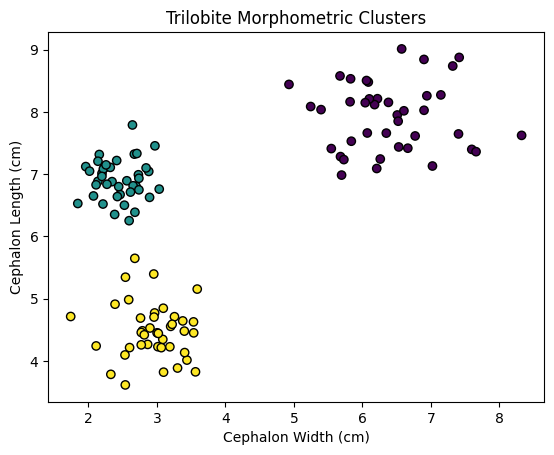

In [ ]:
# Synthetic Fossil Dimensions: [Width (cm), Length (cm)]
np.random.seed(12)
species_1 = np.random.normal([3.0, 4.5], 0.4, (40, 2))
species_2 = np.random.normal([6.5, 8.0], 0.6, (40, 2))
species_3 = np.random.normal([2.5, 7.0], 0.3, (40, 2))
fossil_data = np.vstack([species_1, species_2, species_3])

# --- STUDENT CODE HERE ---
# 1. Initialize KMeans to find 3 distinct clusters
# Hint: Use the n_clusters parameter
kmeans = KMeans(n_clusters=3, random_state=42)

# 2. Fit the model and predict the cluster labels for 'fossil_data'
labels = kmeans.fit_predict(fossil_data)
# --- END STUDENT CODE ---

plt.scatter(fossil_data[:, 0], fossil_data[:, 1], c=labels, cmap='viridis', edgecolor='k')
plt.xlabel("Cephalon Width (cm)")
plt.ylabel("Cephalon Length (cm)")
plt.title("Trilobite Morphometric Clusters")
plt.show()

### Analysis Questions: Paleontology
*(Double click this cell to type your answers below)*

1. **Why is clustering considered "Unsupervised Learning"?**
   * It analyzes the measurements and discovers natural groupings on its own based on similarity
2. **If you ran this algorithm with `n_clusters=2` instead of 3, how would the algorithm decide to group the data?**
   * It would likely merge the two most similar species into one cluster and keep the most distinct group separate

---
## 3. Geology: Mineral Classification (Multilayer Perceptron)

**Scenario:** You are analyzing XRF (X-ray fluorescence) logs from a drilling core. You have chemical percentages for Silica (SiO2), Iron (Fe), and Magnesium (Mg). You want to build a simple Neural Network to classify the rock as **Basalt (0)** or **Granite (1)**.

**Your Task:** Build and train a Multilayer Perceptron (MLP) Classifier. An MLP is a type of feedforward artificial neural network.

In [ ]:
# Features: [Silica%, Iron%, Magnesium%]
# Labels: 0 = Basalt (Low Silica, High Fe/Mg), 1 = Granite (High Silica, Low Fe/Mg)
X_rocks = np.array([
    [48.2, 11.5, 8.2], [45.1, 13.2, 9.1], [50.3, 10.1, 7.5], [49.5, 12.0, 8.0], # Basalts
    [72.5, 2.1, 0.5], [70.1, 3.5, 1.2], [75.4, 1.8, 0.2], [73.0, 2.5, 0.8]      # Granites
])
y_rocks = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# --- STUDENT CODE HERE ---
# 1. Initialize the MLPClassifier.
# Let's use two hidden layers with 10 neurons each: hidden_layer_sizes=(10, 10)
# Set max_iter=1000 so the network has time to converge.
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

# 2. Train (fit) the neural network on the rock data
mlp.fit(X_rocks, y_rocks)

# 3. Predict the classification of a newly drilled rock sample:
# 46% Silica, 12% Iron, 8.5% Magnesium
new_sample = [[46.0, 12.0, 8.5]]
prediction = mlp.predict(new_sample)
# --- END STUDENT CODE ---

rock_type = "Granite" if prediction[0] == 1 else "Basalt"
print(f"The Neural Network classifies the new sample as: {rock_type}")

The Neural Network classifies the new sample as: Basalt


### Analysis Questions: Geology
*(Double click this cell to type your answers below)*

1. **In an MLP, what does a "hidden layer" do?**
   * A hidden layer processes and transforms the input features into more complex representations.
2. **If a rock had exactly 60% Silica, 7% Iron, and 4% Magnesium, do you think the network would be highly confident or uncertain? Why?**
   * The network would likely be uncertain because those values fall between the typical ranges of basalt and granite

---
## 4. Hydrology: Predicting Streamflow Sequences (Recurrent Neural Network)

**Scenario:** Rivers have seasonal flow patterns (high in spring due to snowmelt, low in late summer). You want to predict *next* month's streamflow based on the sequence of the *previous 3 months*.

Because this is **sequential time-series data**, standard feedforward networks (like the MLP above) struggle. Instead, we use a **Recurrent Neural Network (RNN)**, which has a "memory" of previous inputs.

**Your Task:** Complete the RNN architecture to predict the next value in the streamflow sequence.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN...
Training complete!
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


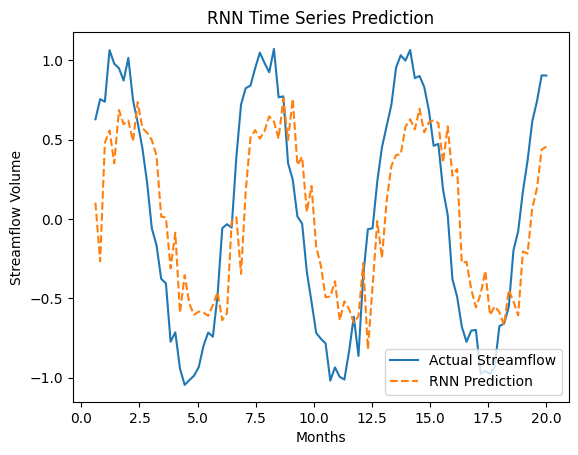

In [ ]:
# Synthetic Streamflow Data: A sine wave with added noise (representing seasons)
time_steps = np.linspace(0, 20, 100)
streamflow = np.sin(time_steps) + np.random.normal(0, 0.1, 100)

# Prepare sequences: Use 3 months to predict the 4th
X_hydro, y_hydro = [], []
for i in range(len(streamflow) - 3):
    X_hydro.append(streamflow[i:i+3])
    y_hydro.append(streamflow[i+3])

X_hydro = np.array(X_hydro).reshape(-1, 3, 1) # Reshape for RNN: (Samples, Time Steps, Features)
y_hydro = np.array(y_hydro)

# Build the RNN
model_rnn = Sequential()

# --- STUDENT CODE HERE ---
# 1. Add a SimpleRNN layer with 10 units.
# The input_shape should match our sequence length and features: (3, 1)
model_rnn.add(SimpleRNN(units=10, input_shape=(3, 1)))

# 2. Add a Dense layer with 1 unit (this outputs our single predicted streamflow value)
model_rnn.add(Dense(units=1))
# --- END STUDENT CODE ---

model_rnn.compile(optimizer='adam', loss='mse')

# Train the model (we will use just 20 epochs for speed in this lab)
print("Training RNN...")
model_rnn.fit(X_hydro, y_hydro, epochs=20, verbose=0)
print("Training complete!")

# Let's predict the sequence and plot
predictions = model_rnn.predict(X_hydro)

plt.plot(time_steps[3:], y_hydro, label="Actual Streamflow")
plt.plot(time_steps[3:], predictions, label="RNN Prediction", linestyle='dashed')
plt.xlabel("Months")
plt.ylabel("Streamflow Volume")
plt.legend()
plt.title("RNN Time Series Prediction")
plt.show()

### Analysis Questions: Hydrology
*(Double click this cell to type your answers below)*

1. **Why is an RNN better suited for streamflow prediction than a standard MLP or Random Forest?**
   * It keeps a memory of previous inputs through its internal state.
2. **If we changed the input sequence from 3 months to 12 months, how might that help the model understand seasonal data?**
   * Using 12 months would give the model a full yearly cycle, allowing it to better learn seasonal patterns like spring peaks and late-summer lows. This longer context helps the RNN recognize repeating annual trends, improving its ability to predict streamflow based on seasonality rather than just short term fluctuations.
